# 1 - AM Grundlagen

## Überblick: Amplitudenmodulation (AM)

Unmodulierter Träger:

$$s_c(t) = U_c \cos(2\pi f_c t + \varphi_c)$$

Basisband (hier z. B. Cosinus):

$$u_m(t) = U_m \cos(2\pi f_m t + \varphi_m)$$

Normiertes Basisband:

$$\hat u_m(t) = \frac{u_m(t)}{\max |u_m(t)|}$$

AM-Signal mit Modulationsgrad $m$:

$$s_{AM}(t) = U_c \left(1 + m \hat u_m(t)\right)\cos(2\pi f_c t + \varphi_c)$$

Für ein Cosinus-Basisband gilt (aus der Hüllkurve):

$$m = \frac{U_{max} - U_{min}}{U_{max} + U_{min}}$$


## Globale Konfiguration 

Hier werden alle gemeinsamen Simulationsparameter zentral gesetzt:

- Gesamtzeitdauer `T_obs`
- Abtastrate `fs`
- Signalpunkte `N_sig`
- FFT-Länge `N_fft`

So bleiben alle folgenden Zellen konsistent und gut vergleichbar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True

# Globale Parameter
T_obs = 0.02            # Beobachtungsdauer [s]
fs = 200_000            # Abtastrate [Hz]
N_sig = int(T_obs * fs) # Anzahl Signalpunkte
N_fft = 16384           # FFT-Länge

# Optionale FFT-Fensterung gegen Leakage
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'

t_plot_ms = 6.0         # konsistente Plotdauer für Zeitbereich [ms]

t = np.arange(N_sig) / fs
n_plot = min(N_sig, int(t_plot_ms * 1e-3 * fs))

print(f'fs = {fs} Hz, T_obs = {T_obs} s, N_sig = {N_sig}, N_fft = {N_fft}, t_plot = {t_plot_ms} ms')

fs = 200000 Hz, T_obs = 0.02 s, N_sig = 4000, N_fft = 16384, t_plot = 6.0 ms


In [2]:
# 1) Unmodulierter Träger: Parameter + Signal
U_c = 1.0              # Trägeramplitude
f_c = 20_000.0         # Trägerfrequenz [Hz]
phi_c_deg = 0.0        # Trägerphase [deg]

phi_c = np.deg2rad(phi_c_deg)
s_c = U_c * np.cos(2*np.pi*f_c*t + phi_c)

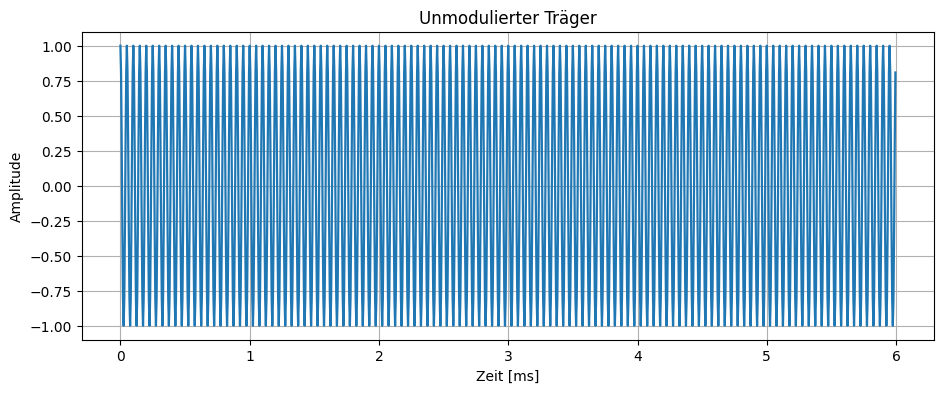

In [3]:
# Plot: unmodulierter Träger (Zeitbereich)
plt.figure()
plt.plot(t[:n_plot]*1e3, s_c[:n_plot], lw=1.6)
plt.title('Unmodulierter Träger')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.show()

In [4]:
# 2) Basisbandsignal: Auswahl + Parameter
# wave_type in {'cosinus', 'dreieck', 'rechteck'}
wave_type = 'cosinus'

U_m = 1.0              # Basisbandamplitude
f_m = 1_000.0          # Basisbandfrequenz [Hz]
phi_m_deg = 0.0        # Basisbandphase [deg]

phi_m = np.deg2rad(phi_m_deg)
phase = 2*np.pi*f_m*t + phi_m

if wave_type == 'cosinus':
    u_m = U_m * np.cos(phase)
elif wave_type == 'dreieck':
    u_m = U_m * (2/np.pi) * np.arcsin(np.sin(phase))
elif wave_type == 'rechteck':
    u_m = U_m * np.sign(np.cos(phase))
else:
    raise ValueError("wave_type muss 'cosinus', 'dreieck' oder 'rechteck' sein.")

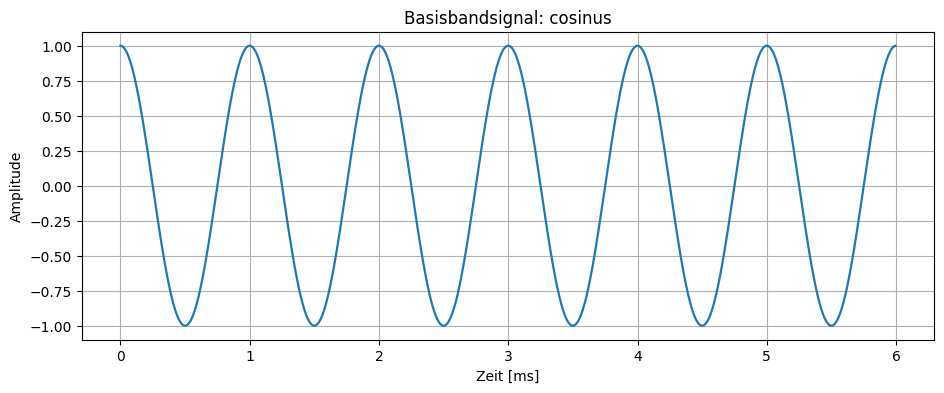

In [5]:
# Plot: Basisbandsignal (Zeitbereich)
plt.figure()
plt.plot(t[:n_plot]*1e3, u_m[:n_plot], lw=1.6)
plt.title(f'Basisbandsignal: {wave_type}')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.show()

## Prinzip der AM

Didaktische Sicht:

1. Wir bilden aus dem Basisband ein normiertes Signal $\hat u_m(t)$.
2. Wir addieren einen DC-Offset: $1 + m \hat u_m(t)$.
3. Diese Hüllkurve multipliziert den Träger.

Formel des Amplitudenmodulators:

$$s_{AM}(t) = U_c\left(1 + m\hat u_m(t)\right)\cos(2\pi f_c t + \varphi_c)$$


In [6]:
# 3) AM-Modulator (Python-Implementierung)
m = 0.6  # Modulationsgrad für U_m = 1.0

# IMPLEMENTIERE den Amplitudenmodulator gemäß den bekannten Formeln
# Ersetze die Platzhalter
u_m_hat = u_m
envelope = np.zeros(N_sig)
s_am = np.zeros(N_sig)

envelope[:] = 1 + m * u_m_hat[:]
s_am[:] = U_c * envelope[:] * np.cos(2 * np.pi * f_c * t[:] + phi_m_deg)

print(f'm = {m:.3f}, min(envelope) = {envelope.min():.3f}, max(envelope) = {envelope.max():.3f}')

m = 0.600, min(envelope) = 0.400, max(envelope) = 1.600


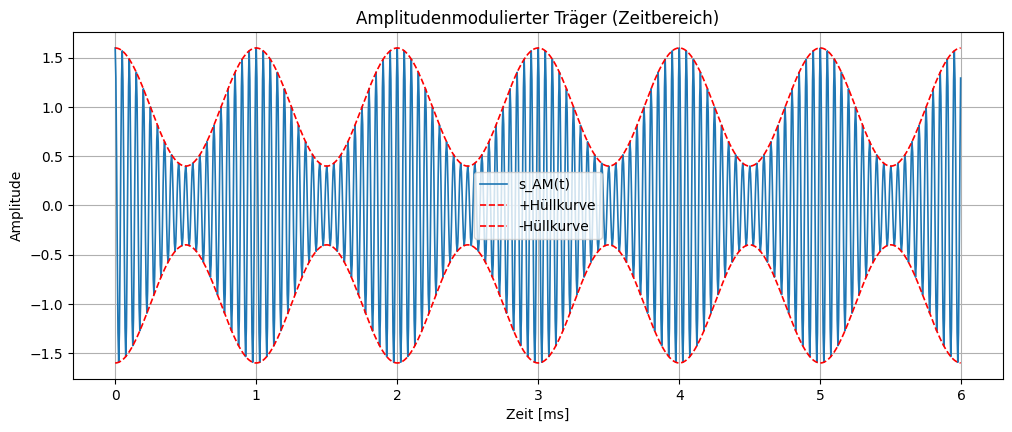

In [7]:
# Plot: AM-Signal im Zeitbereich (mit Hüllkurve)
plt.figure(figsize=(12, 4.5))
plt.plot(t[:n_plot]*1e3, s_am[:n_plot], label='s_AM(t)', lw=1.2)
plt.plot(t[:n_plot]*1e3, (U_c*envelope)[:n_plot], 'r--', lw=1.2, label='+Hüllkurve')
plt.plot(t[:n_plot]*1e3, (-U_c*envelope)[:n_plot], 'r--', lw=1.2, label='-Hüllkurve')
plt.title('Amplitudenmodulierter Träger (Zeitbereich)')
plt.xlabel('Zeit [ms]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [8]:
# 4a) Peak-Suche als eigene Funktion (Sliding-Window-Maximum, ohne SciPy)
def find_peaks_sliding_window(
    a: np.ndarray,
    k: int = 21,
    min_height: float = 0.0,
    return_window_max: bool = False,
):
    """
    Lokale Maxima per Sliding-Window-Maximum.

    Idee:
    1) Für jedes Sample wird das Maximum in einem Fenster der Breite k bestimmt.
    2) Dort, wo ungefiltertes Signal und Fenster-Maximum gleich sind, liegen Peak-Kandidaten.
    3) Zusammenhängende Kandidaten-Plateaus werden auf genau einen Peak reduziert
       (Index des stärksten Samples im Plateau).

    Parameter:
    - a: 1D-Signal
    - k: Fensterbreite (ungerade empfohlen, > 1)
    - min_height: optionale Mindesthöhe
    - return_window_max: falls True, zusätzlich die Sliding-Window-Maximum-Kurve zurückgeben
    """
    x = np.asarray(a, dtype=float).ravel()
    n = x.size
    if n == 0:
        return np.array([], dtype=int)

    k = max(3, int(k))
    if k % 2 == 0:
        k += 1
    h = k // 2

    # Sliding-Window-Maximum (didaktisch klar, nicht auf Laufzeit optimiert)
    max_filt = np.empty(n, dtype=float)
    for i in range(n):
        i0 = max(0, i - h)
        i1 = min(n, i + h + 1)
        max_filt[i] = np.max(x[i0:i1])

    # Peak-Kandidaten: Original trifft Fenster-Maximum + Mindesthoehe
    cand = np.isclose(x, max_filt, rtol=0.0, atol=1e-14) & (x >= float(min_height))
    idx = np.flatnonzero(cand)
    if idx.size == 0:
        return np.array([], dtype=int)

    # Kandidaten-Plateaus zu je einem Peak zusammenfassen
    groups = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    peaks = []
    for g in groups:
        j = g[np.argmax(x[g])]
        peaks.append(int(j))

    peaks = np.array(peaks, dtype=int)
    if return_window_max:
        return peaks, max_filt
    return peaks


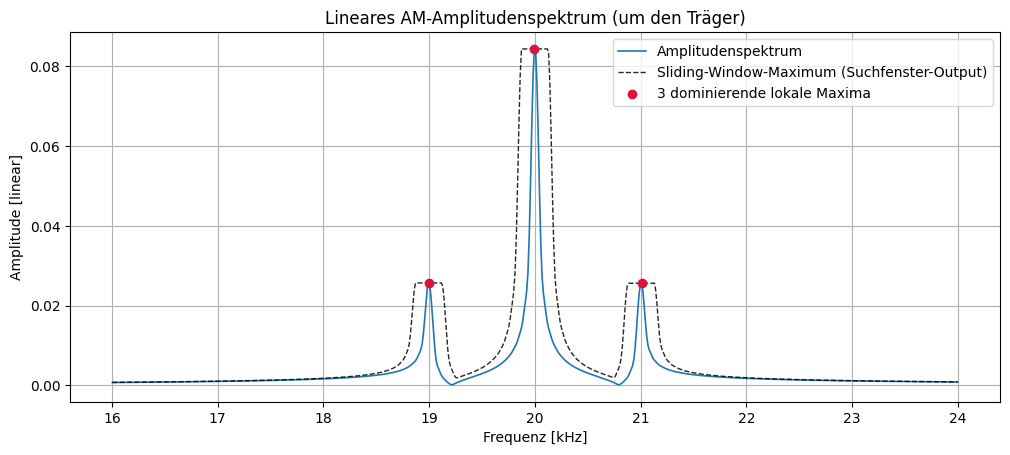

Spektrale Auflösung: df = 12.207 Hz
Peak-Suche (Sliding-Window): window = 20 Bins (~250.0 Hz), min_height >= 1.6880e-03
Die gestrichelte Kurve zeigt den Output des Suchfensters (Sliding-Window-Maximum).

--- Modulationsgrad aus Spektrum ---
m_est,lo = 0.6084, m_est,hi = 0.6069, m_est = 0.6076

--- Erkannte Spektrallinien (Tabelle) ---


,Linie,Frequenz [Hz],Delta zu Träger [Hz],Amplitude [linear],m aus Linie
0,Seitenlinie unten,18994.140625,-1000.976562,0.025674,0.608384
1,Träger,19995.117187,0.000000,0.084399,NaN
2,Seitenlinie oben,21008.300781,1013.183594,0.025609,0.606855


In [9]:
# 4) Spektrum berechnen und plotten (lineares Amplitudenspektrum)
import pandas as pd
from IPython.display import display

x = np.zeros(N_fft)
n_copy = min(N_sig, N_fft)
x[:n_copy] = s_am[:n_copy]

if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w = np.hanning(N_fft)
    elif FFT_WINDOW_KIND == 'hamming':
        w = np.hamming(N_fft)
    else:
        w = np.ones(N_fft)
else:
    w = np.ones(N_fft)

X = np.fft.fft(x * w, n=N_fft)
f = np.fft.fftfreq(N_fft, d=1/fs)

# Einseitiges lineares Amplitudenspektrum (kohärente Verstärkung kompensieren)
cg = np.mean(w)
mask = f >= 0
f_pos = f[mask]
A_pos = (2.0 / (N_fft * max(cg, 1e-12))) * np.abs(X[mask])

df = fs / N_fft

# Suchfenster um den erwarteten Träger
band = (f_pos >= max(0.0, f_c - 4*f_m)) & (f_pos <= (f_c + 4*f_m))
f_band = f_pos[band]
A_band = A_pos[band]

# WICHTIG (didaktisch): lokale Maxima per Sliding-Window-Maximum.
# Eine Spektrallinie ist oft breiter als 1 FFT-Bin; daher erst Peak-Kandidaten als
# "Original == Fenstermaximum" bestimmen und dann die stärksten auswählen.

# Parametrierung der transparenten Peak-Suche
peak_window_hz = max(0.25 * f_m, 8 * df)                   # Fensterbreite [Hz]
peak_window_bins = max(3, int(np.round(peak_window_hz / df)))
peak_min_height = 0.02 * np.max(A_band)

peaks, A_winmax = find_peaks_sliding_window(
    A_band,
    k=peak_window_bins,
    min_height=peak_min_height,
    return_window_max=True,
)

# Aus Peaks die 3 stärksten nehmen (Fallback: rohe Top-3-Samples)
if peaks.size >= 3:
    peak_amps = A_band[peaks]
    idx_sel = peaks[np.argsort(peak_amps)[-3:]]
else:
    idx_sel = np.argsort(A_band)[-3:]

idx_sorted_freq = idx_sel[np.argsort(f_band[idx_sel])]

f1, f2, f3 = f_band[idx_sorted_freq]
A1, A2, A3 = A_band[idx_sorted_freq]

# Träger ist die stärkste der drei Linien
amps = np.array([A1, A2, A3])
freqs = np.array([f1, f2, f3])
idx_c = int(np.argmax(amps))

f_c_est = freqs[idx_c]
U_c_est = amps[idx_c]

sb_freqs = np.delete(freqs, idx_c)
sb_amps = np.delete(amps, idx_c)

# Untere/obere Seitenlinie relativ zum Träger sortieren
order_sb = np.argsort(sb_freqs)
f_sb_lo, f_sb_hi = sb_freqs[order_sb]
U_sb_lo, U_sb_hi = sb_amps[order_sb]

Delta_f_lo = f_c_est - f_sb_lo
Delta_f_hi = f_sb_hi - f_c_est

# Modulationsgrad aus Spektrum: U_SB = (m/2) * U_C -> m = 2*U_SB/U_C
m_est_lo = 2 * U_sb_lo / max(U_c_est, 1e-12)
m_est_hi = 2 * U_sb_hi / max(U_c_est, 1e-12)
m_est = 0.5 * (m_est_lo + m_est_hi)

plt.figure(figsize=(12, 4.8))
plt.plot(f_band/1e3, A_band, lw=1.2, label='Amplitudenspektrum')
plt.plot(
    f_band/1e3,
    A_winmax,
    'k--',
    lw=1.0,
    alpha=0.85,
    label='Sliding-Window-Maximum (Suchfenster-Output)',
)
plt.scatter(freqs/1e3, amps, color='crimson', zorder=4, label='3 dominierende lokale Maxima')
plt.title('Lineares AM-Amplitudenspektrum (um den Träger)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [linear]')
plt.legend()
plt.show()

print(f'Spektrale Auflösung: df = {df:.3f} Hz')
print(
    f"Peak-Suche (Sliding-Window): window = {peak_window_bins} Bins (~{peak_window_hz:.1f} Hz), "
    f"min_height >= {peak_min_height:.4e}"
)
print('Die gestrichelte Kurve zeigt den Output des Suchfensters (Sliding-Window-Maximum).')
print('\n--- Modulationsgrad aus Spektrum ---')
print(f'm_est,lo = {m_est_lo:.4f}, m_est,hi = {m_est_hi:.4f}, m_est = {m_est:.4f}')

# Tabelle der 3 dominanten Spektrallinien
df_lines = pd.DataFrame([
    {
        'Linie': 'Seitenlinie unten',
        'Frequenz [Hz]': float(f_sb_lo),
        'Delta zu Träger [Hz]': float(-Delta_f_lo),
        'Amplitude [linear]': float(U_sb_lo),
        'm aus Linie': float(m_est_lo),
    },
    {
        'Linie': 'Träger',
        'Frequenz [Hz]': float(f_c_est),
        'Delta zu Träger [Hz]': 0.0,
        'Amplitude [linear]': float(U_c_est),
        'm aus Linie': np.nan,
    },
    {
        'Linie': 'Seitenlinie oben',
        'Frequenz [Hz]': float(f_sb_hi),
        'Delta zu Träger [Hz]': float(Delta_f_hi),
        'Amplitude [linear]': float(U_sb_hi),
        'm aus Linie': float(m_est_hi),
    },
])

print('\n--- Erkannte Spektrallinien (Tabelle) ---')
display(df_lines)
